In [10]:
"""
Descarga de gasoductos para análisis de localización planta biometano
Provincia de Huesca

Fuentes:
  1. OpenStreetMap (Overpass) — gasoductos mapeados en OSM
  2. BTN100 IGN — capa Conducciones (descarga manual indicada en comentarios)

Output: gasoductos_huesca.gpkg
"""

import geopandas as gpd
import requests
import json
import time
from pathlib import Path
from shapely.geometry import shape, LineString
from shapely.ops import unary_union

# ─────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────
GEOJSON_HUESCA = r"C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data/delim_huesca.geojson"
OUTPUT_DIR     = Path(r"C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data")
OUTPUT_GPKG    = r"C:/Users/rasan.DESKTOP-5HBGCNN/Desktop/TFM/gasoductos_huesca.gpkg"

CRS_UTM = "EPSG:25830"

# BBox de Huesca en WGS84 (miny, minx, maxy, maxx) — orden Overpass
BBOX_OVERPASS = "41.347806,-0.934168,42.921806,0.771832"


# ─────────────────────────────────────────────────────────
# 1. DESCARGA OSM — GASODUCTOS
# ─────────────────────────────────────────────────────────
def descargar_osm_gasoductos():
    """
    Descarga gasoductos de OpenStreetMap via Overpass API.
    Etiquetas: man_made=pipeline + substance=gas/natural_gas
    """
    print("Descargando gasoductos OSM...")

    query = f"""
    [out:json][timeout:120];
    (
      way["man_made"="pipeline"]["substance"~"gas|natural_gas"]({BBOX_OVERPASS});
      way["pipeline"="gas"]({BBOX_OVERPASS});
      relation["man_made"="pipeline"]["substance"~"gas|natural_gas"]({BBOX_OVERPASS});
    );
    out geom;
    """

    endpoints = [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]
    headers = {"User-Agent": "biometano-huesca-research/1.0 (academic)"}

    for url in endpoints:
        try:
            r = requests.post(url, data={"data": query},
                              headers=headers, timeout=150)
            if r.status_code == 200:
                elements = r.json().get("elements", [])
                print(f"  {len(elements)} elementos encontrados ({url})")

                lineas = []
                for el in elements:
                    if "geometry" in el:
                        coords = [(pt["lon"], pt["lat"])
                                  for pt in el["geometry"]]
                        if len(coords) >= 2:
                            tags = el.get("tags", {})
                            lineas.append({
                                "osm_id":    el.get("id"),
                                "nombre":    tags.get("name", ""),
                                "operador":  tags.get("operator", ""),
                                "substance": tags.get("substance", "gas"),
                                "tipo":      tags.get("pipeline", ""),
                                "presion":   tags.get("pressure", ""),
                                "fuente":    "OSM",
                                "geometry":  LineString(coords)
                            })

                if lineas:
                    gdf = gpd.GeoDataFrame(lineas, crs="EPSG:4326").to_crs(CRS_UTM)
                    print(f"  {len(gdf)} tramos de gasoducto en Huesca")
                    return gdf
                else:
                    print("  Sin geometrías válidas en OSM")
                    return None

        except Exception as e:
            print(f"  {url} falló: {e}")
            time.sleep(3)

    print("  Todos los endpoints fallaron")
    return None


# ─────────────────────────────────────────────────────────
# 2. BTN100 IGN — INSTRUCCIONES DE DESCARGA MANUAL
# ─────────────────────────────────────────────────────────
def instrucciones_btn100():
    print()
    print("=" * 60)
    print("  BTN100 IGN — DESCARGA MANUAL (complemento a OSM)")
    print("=" * 60)
    print()
    print("  1. Ve a:")
    print("     https://centrodedescargas.cnig.es/CentroDescargas/btn100")
    print()
    print("  2. Haz clic en 'Conducciones' → Descargar")
    print("     (shapefile de toda España, ~50 MB)")
    print()
    print("  3. Descomprime y busca el archivo:")
    print("     BTN100_*_CONDUCCION_L.shp")
    print()
    print("  4. Copia ese .shp (+ .shx, .dbf, .prj) a:")
    print(f"     {OUTPUT_DIR}")
    print()
    print("  5. Ejecuta la función cargar_btn100() de este script")
    print("=" * 60)
    print()


def cargar_btn100(ruta_shp: str):
    """
    Carga la capa Conducciones del BTN100, filtra gasoductos
    y recorta a Huesca. Ejecutar tras descarga manual.

    ruta_shp: ruta al archivo BTN100_*_CONDUCCION_L.shp
    """
    print(f"Cargando BTN100 Conducciones: {ruta_shp}")
    huesca = gpd.read_file(GEOJSON_HUESCA).to_crs(CRS_UTM)
    huesca_union = unary_union(huesca.geometry)

    gdf = gpd.read_file(ruta_shp).to_crs(CRS_UTM)
    print(f"  Total conducciones España: {len(gdf)}")
    print(f"  Columnas: {gdf.columns.tolist()}")

    # Filtrar gasoductos (el BTN100 usa campo 'condType' o 'TIPO')
    # Valores típicos: 'Gas', 'GasNatural', 'GN', etc.
    col_tipo = next((c for c in gdf.columns
                     if c.lower() in ["condtype","tipo","type","naturaleza"]), None)
    if col_tipo:
        print(f"  Valores únicos en '{col_tipo}': {gdf[col_tipo].unique()}")
        gdf_gas = gdf[gdf[col_tipo].astype(str).str.contains(
            "gas|GN|gasoducto", case=False, na=False)].copy()
        print(f"  Gasoductos filtrados: {len(gdf_gas)}")
    else:
        print("  No se encontró columna de tipo — usando todas las conducciones")
        gdf_gas = gdf.copy()

    # Clip a Huesca + buffer de 10 km
    gdf_huesca = gdf_gas[gdf_gas.geometry.intersects(
        huesca_union.buffer(10_000))].copy()
    print(f"  Conducciones en Huesca (+10km buffer): {len(gdf_huesca)}")
    gdf_huesca["fuente"] = "BTN100_IGN"
    return gdf_huesca


# ─────────────────────────────────────────────────────────
# 3. GUARDAR Y CALCULAR DISTANCIAS
# ─────────────────────────────────────────────────────────
def guardar_gasoductos(gdf_osm, gdf_btn100=None):
    """Combina fuentes y guarda GPKG."""
    capas = []
    if gdf_osm is not None and len(gdf_osm) > 0:
        capas.append(gdf_osm)
    if gdf_btn100 is not None and len(gdf_btn100) > 0:
        capas.append(gdf_btn100[["geometry", "fuente"]])

    if not capas:
        print("Sin gasoductos para guardar.")
        return None

    import pandas as pd
    gdf_final = pd.concat(capas, ignore_index=True)
    gdf_final = gpd.GeoDataFrame(gdf_final, crs=CRS_UTM)

    gdf_final.to_file(OUTPUT_GPKG, driver="GPKG", layer="gasoductos")
    print(f"\n  GPKG guardado: {OUTPUT_GPKG}")
    print(f"  Total tramos: {len(gdf_final)}")
    return gdf_final


def calcular_distancia_gasoducto(gdf_granjas, gdf_gasoductos):
    """
    Añade columna 'dist_gasoducto_m' al GeoDataFrame de granjas.
    Distancia en metros desde cada granja al gasoducto más cercano.
    """
    print("\nCalculando distancias granja → gasoducto...")

    # Unir todos los tramos en una sola geometría
    red_gas = unary_union(gdf_gasoductos.geometry)

    gdf_granjas = gdf_granjas.copy()
    gdf_granjas["dist_gasoducto_m"] = gdf_granjas.geometry.distance(red_gas).round(0)

    print(f"  Distancia media:   {gdf_granjas['dist_gasoducto_m'].mean():.0f} m")
    print(f"  Distancia mínima:  {gdf_granjas['dist_gasoducto_m'].min():.0f} m")
    print(f"  Distancia máxima:  {gdf_granjas['dist_gasoducto_m'].max():.0f} m")
    print(f"  Granjas < 5 km:    {(gdf_granjas['dist_gasoducto_m'] < 5000).sum()}")
    print(f"  Granjas < 15 km:   {(gdf_granjas['dist_gasoducto_m'] < 15000).sum()}")

    return gdf_granjas


# ─────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────
if __name__ == "__main__":

    print("\n" + "="*60)
    print("  GASODUCTOS HUESCA — DESCARGA Y ANÁLISIS")
    print("="*60 + "\n")

    # 1. OSM
    gdf_osm = descargar_osm_gasoductos()

    # 2. BTN100 — instrucciones para descarga manual
    instrucciones_btn100()

    # 3. Guardar lo que tenemos de OSM
    gdf_gas = guardar_gasoductos(gdf_osm)

    # 4. Si tienes el gdf de granjas en memoria, calcula distancias
    # (descomenta cuando tengas gdf cargado)
    # gdf_con_dist = calcular_distancia_gasoducto(gdf, gdf_gas)
    # gdf_con_dist.to_file(OUTPUT_DIR / "granjas_con_distancias.gpkg",
    #                       driver="GPKG", layer="granjas")

    print("\nCuando descargues el BTN100, ejecuta:")
    print("  gdf_btn = cargar_btn100('ruta/al/BTN100_CONDUCCION_L.shp')")
    print("  gdf_gas = guardar_gasoductos(gdf_osm, gdf_btn)")



  GASODUCTOS HUESCA — DESCARGA Y ANÁLISIS

Descargando gasoductos OSM...
  97 elementos encontrados (https://overpass-api.de/api/interpreter)
  97 tramos de gasoducto en Huesca

  BTN100 IGN — DESCARGA MANUAL (complemento a OSM)

  1. Ve a:
     https://centrodedescargas.cnig.es/CentroDescargas/btn100

  2. Haz clic en 'Conducciones' → Descargar
     (shapefile de toda España, ~50 MB)

  3. Descomprime y busca el archivo:
     BTN100_*_CONDUCCION_L.shp

  4. Copia ese .shp (+ .shx, .dbf, .prj) a:
     C:\Users\rasan.DESKTOP-5HBGCNN\QGIS_data

  5. Ejecuta la función cargar_btn100() de este script


  GPKG guardado: C:/Users/rasan.DESKTOP-5HBGCNN/Desktop/TFM/gasoductos_huesca.gpkg
  Total tramos: 97

Cuando descargues el BTN100, ejecuta:
  gdf_btn = cargar_btn100('ruta/al/BTN100_CONDUCCION_L.shp')
  gdf_gas = guardar_gasoductos(gdf_osm, gdf_btn)


In [2]:
gdf_btn = cargar_btn100(r"C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data/Conducciones/BTN100_0701L_COND_COMB.shp")
gdf_gas = guardar_gasoductos(gdf_osm, gdf_btn)

Cargando BTN100 Conducciones: C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data/Conducciones/BTN100_0701L_COND_COMB.shp
  Total conducciones España: 107
  Columnas: ['ID', 'ID_BD', 'ID_CODIGO', 'ID_MOD', 'FECHA_ALTA', 'SITUACION', 'TIPO_0701', 'geometry']
  No se encontró columna de tipo — usando todas las conducciones
  Conducciones en Huesca (+10km buffer): 4

  GPKG guardado: C:\Users\rasan.DESKTOP-5HBGCNN\QGIS_data\gasoductos_huesca.gpkg
  Total tramos: 101


C:\Users\rasan.DESKTOP-5HBGCNN\AppData\Local\Temp\ipykernel_14748\1718914757.py:90: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
C:\Users\rasan.DESKTOP-5HBGCNN\AppData\Local\Temp\ipykernel_14748\1718914757.py:90: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")


Guardado: C:\Users\rasan.DESKTOP-5HBGCNN\QGIS_data\comparacion_osm_btn100.png


c:\Users\rasan.DESKTOP-5HBGCNN\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rasan.DESKTOP-5HBGCNN\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


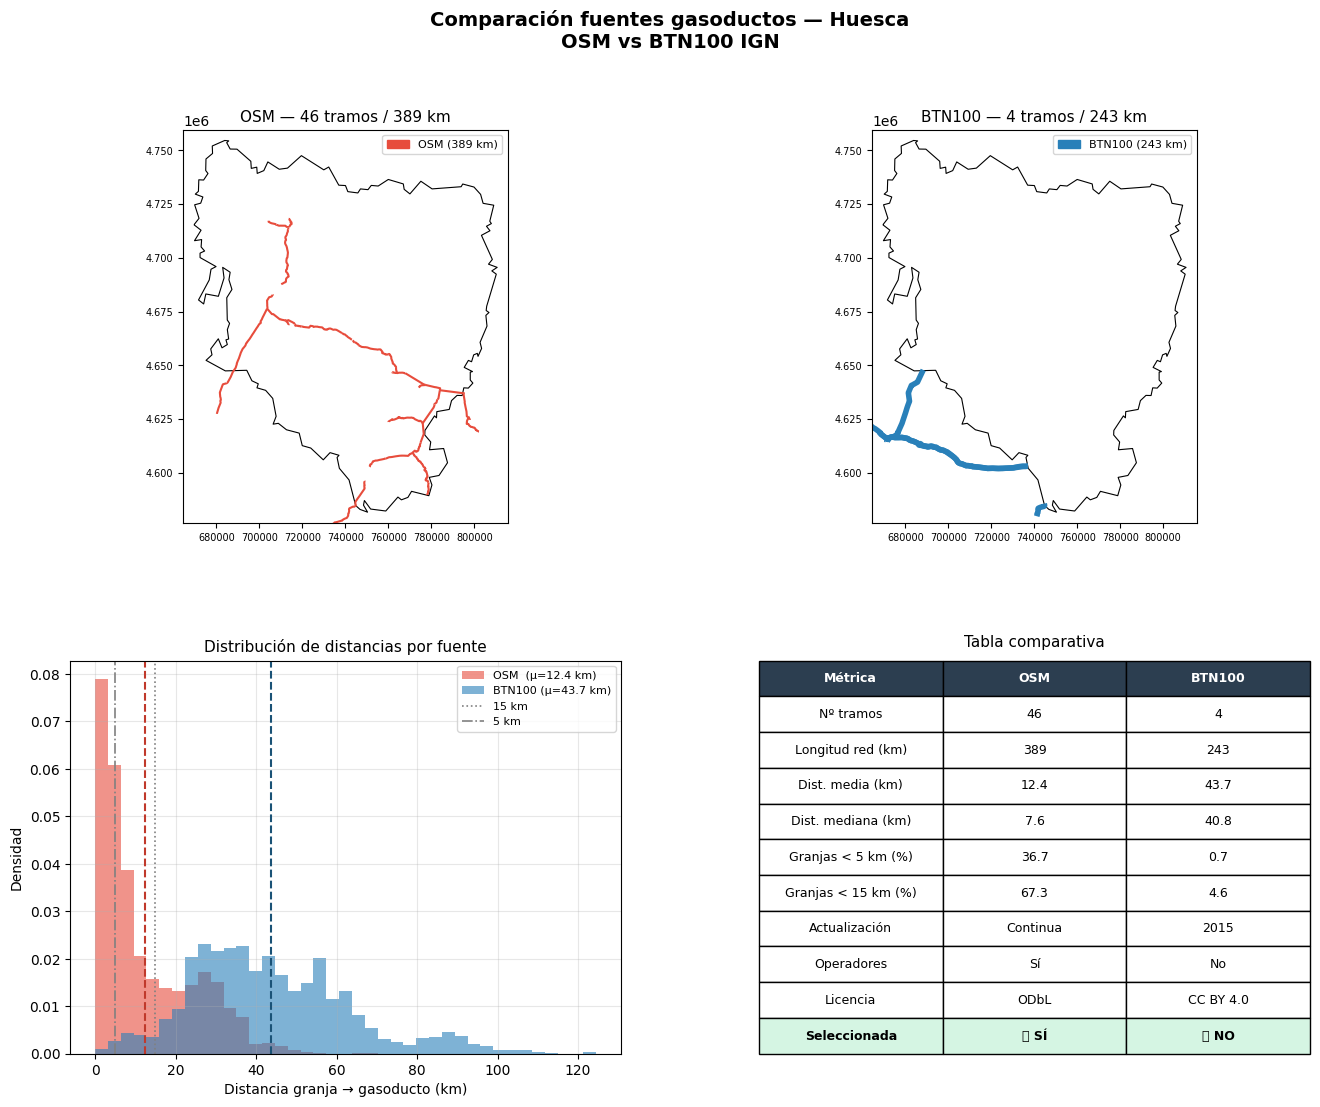

In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.ops import unary_union
from pathlib import Path
from geopandas import GeoDataFrame as gdf

gdf = gpd.read_file(
    r"c:\Users\rasan.DESKTOP-5HBGCNN\Desktop\QGIS_data\granjas_porcino_huesca.gpkg"
).to_crs("EPSG:25830")
GEOJSON_HUESCA = r"C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data/delim_huesca.geojson"
OUTPUT_DIR     = Path(r"C:/Users/rasan.DESKTOP-5HBGCNN/QGIS_data")
OUTPUT_PNG     = OUTPUT_DIR / "comparacion_osm_btn100.png"
OUTPUT_CSV     = OUTPUT_DIR / "comparacion_osm_btn100.csv"
CRS_UTM = "EPSG:25830"

huesca   = gpd.read_file(GEOJSON_HUESCA).to_crs(CRS_UTM)
h_union  = unary_union(huesca.geometry)
h_buf    = h_union.buffer(10_000)

osm_clip = gdf_osm[gdf_osm.geometry.intersects(h_buf)].copy()
btn_clip = gdf_btn[gdf_btn.geometry.intersects(h_buf)].copy()

km_osm = osm_clip.geometry.length.sum() / 1000
km_btn = btn_clip.geometry.length.sum() / 1000

red_osm  = unary_union(osm_clip.geometry)
red_btn  = unary_union(btn_clip.geometry)
dist_osm = gdf.geometry.distance(red_osm) / 1000
dist_btn = gdf.geometry.distance(red_btn) / 1000

# ── Figura 4 paneles ──────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Comparación fuentes gasoductos — Huesca\nOSM vs BTN100 IGN",
             fontsize=14, fontweight="bold", y=0.98)
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
bounds = h_union.bounds

for ax, gdf_l, color, label, km, lw in [
    (ax1, osm_clip, "#e74c3c", "OSM",    km_osm, 1.5),
    (ax2, btn_clip, "#2980b9", "BTN100", km_btn, 4.0)]:  # más grueso
    huesca.boundary.plot(ax=ax, color="black", linewidth=0.8)
    if len(gdf_l): gdf_l.plot(ax=ax, color=color, linewidth=lw)
    ax.set_xlim(bounds[0]-5000, bounds[2]+5000)
    ax.set_ylim(bounds[1]-5000, bounds[3]+5000)
    ax.set_title(f"{label} — {len(gdf_l)} tramos / {km:.0f} km", fontsize=11)
    ax.tick_params(labelsize=7)
    ax.legend(handles=[mpatches.Patch(color=color, label=f"{label} ({km:.0f} km)")], fontsize=8)

bins = np.linspace(0, max(dist_osm.max(), dist_btn.max()), 40)
ax3.hist(dist_osm, bins=bins, alpha=0.6, color="#e74c3c", label=f"OSM  (μ={dist_osm.mean():.1f} km)", density=True)
ax3.hist(dist_btn, bins=bins, alpha=0.6, color="#2980b9", label=f"BTN100 (μ={dist_btn.mean():.1f} km)", density=True)
ax3.axvline(dist_osm.mean(), color="#c0392b", linestyle="--", linewidth=1.5)
ax3.axvline(dist_btn.mean(), color="#1a5276", linestyle="--", linewidth=1.5)
ax3.axvline(15, color="gray", linestyle=":", linewidth=1.2, label="15 km")
ax3.axvline(5,  color="gray", linestyle="-.", linewidth=1.2, label="5 km")
ax3.set_xlabel("Distancia granja → gasoducto (km)"); ax3.set_ylabel("Densidad")
ax3.set_title("Distribución de distancias por fuente", fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

ax4.axis("off")
filas = [
    ["Nº tramos",             str(len(osm_clip)),              str(len(btn_clip))],
    ["Longitud red (km)",     f"{km_osm:.0f}",                 f"{km_btn:.0f}"],
    ["Dist. media (km)",      f"{dist_osm.mean():.1f}",        f"{dist_btn.mean():.1f}"],
    ["Dist. mediana (km)",    f"{dist_osm.median():.1f}",      f"{dist_btn.median():.1f}"],
    ["Granjas < 5 km (%)",   f"{(dist_osm<5).mean()*100:.1f}", f"{(dist_btn<5).mean()*100:.1f}"],
    ["Granjas < 15 km (%)",  f"{(dist_osm<15).mean()*100:.1f}",f"{(dist_btn<15).mean()*100:.1f}"],
    ["Actualización",        "Continua",                       "2015"],
    ["Operadores",           "Sí",                             "No"],
    ["Licencia",             "ODbL",                           "CC BY 4.0"],
    ["Seleccionada",         "✅ SÍ",                          "❌ NO"],
]
tabla = ax4.table(cellText=filas, colLabels=["Métrica","OSM","BTN100"],
                  cellLoc="center", loc="center", bbox=[0,0,1,1])
tabla.auto_set_font_size(False); tabla.set_fontsize(9)
for j in range(3):
    tabla[0,j].set_facecolor("#2c3e50")
    tabla[0,j].set_text_props(color="white", fontweight="bold")
    tabla[len(filas),j].set_facecolor("#d5f5e3")
    tabla[len(filas),j].set_text_props(fontweight="bold")
ax4.set_title("Tabla comparativa", fontsize=11, pad=10)

plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Guardado: {OUTPUT_PNG}")